${\large Oppgave\ 6\ Varmeligning}$


a)
Gjenstanden som skal brukes skal være et tverrsnitt av en gran/furu. Trevirke generelt ligger på en diffusivitet på:  $0.08 - 0.16\,\text{mm}^2/\text{s}$

Mens gran/Furu ligger i området: $0.13 - 0.14\,\text{mm}^2/\text{s}$

Velger derfor å bruke verdien: 
$$\alpha = 0.14\,\text{mm}^2/\text{s}$$

For å gjøre varmeplottene mer oversiktlig velger jeg å omskrive verdien $alpha$ slik at: 
$$\alpha = 0.084\,\text{cm}^2/\text{min}$$

Ønsker å vite hvordan diffusiviteten oppfører seg i en standard $48x98 {mm}$ konstruksjonsvirke. Velger å forenkle, slik at koordinatene som beskriver $x$ og $y$ er: 
$$-5 < x < 5,\; 0 < y < 5.$$
For $x$ og $y$ verdier i cm





b) Ser på differensiallikningen

$$
\begin{align}
u_t = \alpha\cdot(u_{xx} + u_{yy}), \quad -5<x<5, 0<y<5
\end{align}
$$

Bruker initialbetingelsene
$$\begin{align}u(x,y,0) = 15\end{align}$$

Og følgende randbetingelser:
$$
\begin{align}
u(-5,y,t) = 200, \quad & 0\leq y \leq 5 \\
u(5,y,t) = 200, \quad & 0\leq y \leq 5 \\
u(x,0,t) = 200, \quad & -5\leq x \leq 5 \\
u(x,5,t) = 200, \quad & -5 \leq x \leq 5
\end{align}
$$

In [1]:
# kode for plot

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

alpha = 0.084  # cm^2/min   # Termisk diffusitet av K-virke

m = 15
x = np.linspace(-5, 5, m + 2)
dx = x[1] - x[0]

n = 30
y = np.linspace(0, 5, n + 2)
dy = y[1] - y[0]

nt = 300  # nt+1 antall t-verdier
t = np.linspace(0, 120, nt + 1)
dt = t[1] - t[0]
dt_maks = (1 / 2 * dx**2) / alpha  # anbefalt maks verdi for dt
print(f"dt burde ikke overskride verdien {dt_maks}.")
print(f"dt sin verdi er {dt}")

#   Uttrykket for temperatur i tverrsnittet
u = np.zeros((nt + 1, m + 2, n + 2))  # u(t,x,y)

#   Initialbetingelse
u[0, 1:-1, 1:-1] = 15  # Grader Celcius

#   Randbetingelser
u[:, :, -1] = 200  # Grader Celcius
u[:, :, 0] = 200  # Grader Celcius
u[:, 0, :] = 200  # Grader Celcius
u[:, -1, :] = 200  # Grader Celcius

# euler
for i in range(nt):
    uxx = 1 / dx**2 * (u[i, :-2, 1:-1] - 2 * u[i, 1:-1, 1:-1] + u[i, 2:, 1:-1])
    uyy = 1 / dx**2 * (u[i, 1:-1, :-2] - 2 * u[i, 1:-1, 1:-1] + u[i, 1:-1, 2:])
    u[i + 1, 1:-1, 1:-1] = u[i, 1:-1, 1:-1] + dt * alpha * (uxx + uyy)

dt burde ikke overskride verdien 2.3251488095238093.
dt sin verdi er 0.4


C:\Users\Henrik\AppData\Local\Temp\ipykernel_40268\1175643965.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # gjør plass til fargeskalaen


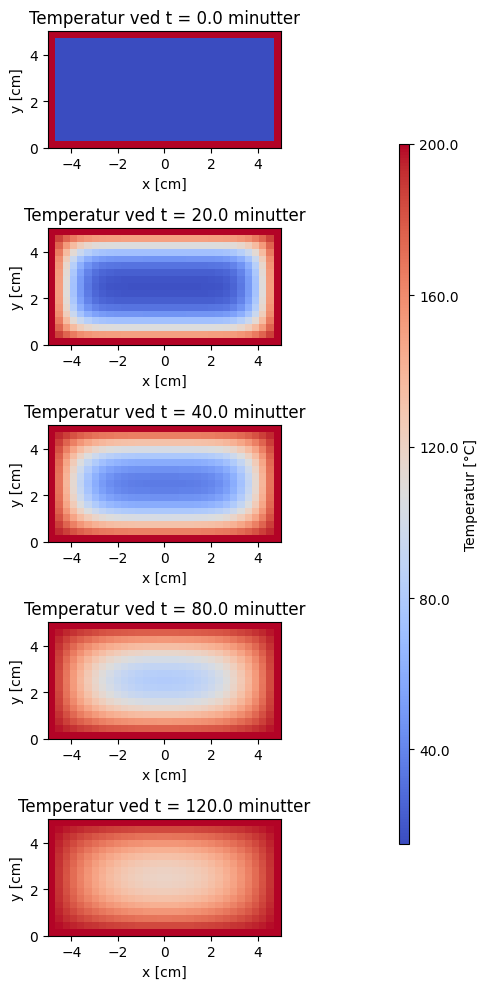

In [2]:
# Plotting av oppg 6
#
# Velger hvilke tidspunkter som skal plottes
tider = [0, 50, 100, 200, -1]

#   Lager figuren
fig, axs = plt.subplots(len(tider), 1, figsize=(5, 10))

# Setter inn riktige verdier på x- og y-akse
extent = [x.min(), x.max(), y.min(), y.max()]

# Lager plot for de forskjellige tidspunktene
for i, tid in enumerate(tider):
    im = axs[i].imshow(
        u[tid, :, :],
        cmap="coolwarm",
        origin="lower",
        extent=extent,
        aspect="equal",
        vmin=u.min(),
        vmax=u.max(),
    )
    axs[i].set_title(f"Temperatur ved t = {t[tid]:.1f} minutter")
    axs[i].set_xlabel("x [cm]")
    axs[i].set_ylabel("y [cm]")

# Felles fargeskala
# Lager en egen akse for fargeskalaen til høyre
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)

# Ryddigere tallformat
cbar.locator = MaxNLocator(nbins=6)  # maks 6 tick-verdier
cbar.formatter = FormatStrFormatter("%.1f")  # én desimal, ingen eksponent
cbar.update_ticks()
cbar.set_label("Temperatur [°C]")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # gjør plass til fargeskalaen
plt.show()


${\large Oppgave\ 7\ Luften\ skal\ med}$

Her skal den termiske diffusjonen til luft legges inn. Den har verdien: $22\,\text{mm}^2/\text{s}$

Det må så settes inn initialbetingelser for luftlaget ved $t=0$: 

$$\begin{align}u(x,y,0) = 200\end{align}$$

Og følgende randbetingelser gjelder for luftlaget: 


In [4]:
# Kode for plot oppgave 7
# 
# 
alpha_luft = 13.2  # cm^2/min eller 22mm^2/s   # Termisk diffusitet av luft

m_2 = 30
x_2 = np.linspace(-10, 10, m_2 + 2)
dx_2 = x_2[1] - x_2[0]

n_2 = 60
y_2 = np.linspace(-2.5, 7.5, n_2 + 2)
dy_2 = y_2[1] - y_2[0]

#   Uttrykket for temperatur i hele ovnen (med planken)
u_2 = np.zeros((nt + 1, m_2 + 2, n_2 + 2))  # u(t,x,y)

#   Initialbetingelse
u_2[0, 1:-1, 1:-1] = 200  # temperaturen til luften i ovenen

#   Randbetingelser for luften
u_2[:, :, -1] = 200  # Grader Celcius
u_2[:, :, 0] = 200  # Grader Celcius
u_2[:, 0, :] = 200  # Grader Celcius
u_2[:, -1, :] = 200  # Grader Celcius

_, Bx, By = u_2.shape
_, Sx, Sy = u.shape

# Start- og sluttindekser for "planke" inni ovnen
x0 = (Bx - Sx) // 2
x1 = x0 + Sx

y0 = (By - Sy) // 2
y1 = y0 + Sy


# euler
for i in range(nt):
    #   Finner verdier for luft i ovnen
    uxx_2 = (
        1 / dx_2**2 * (u_2[i, :-2, 1:-1] - 2 * u_2[i, 1:-1, 1:-1] + u_2[i, 2:, 1:-1])
    )
    uyy_2 = (
        1 / dx_2**2 * (u_2[i, 1:-1, :-2] - 2 * u_2[i, 1:-1, 1:-1] + u_2[i, 1:-1, 2:])
    )
    u_2[i + 1, 1:-1, 1:-1] = u_2[i, 1:-1, 1:-1] + dt * alpha_luft * (uxx_2 + uyy_2)

    #   Legger inn randbetingelse for "planke"
    u[i, :, -1] = u_2[i, x0:x1, y1]  # Grader Celcius
    u[i, :, 0] = u_2[i, x0:x1, y0]  # Grader Celcius
    u[i, 0, :] = u_2[i, x0, y0:y1]  # Grader Celcius
    u[i, -1, :] = u_2[i, x1, y0:y1]  # Grader Celcius

    uxx = 1 / dx**2 * (u[i, :-2, 1:-1] - 2 * u[i, 1:-1, 1:-1] + u[i, 2:, 1:-1])
    uyy = 1 / dx**2 * (u[i, 1:-1, :-2] - 2 * u[i, 1:-1, 1:-1] + u[i, 1:-1, 2:])
    u[i + 1, 1:-1, 1:-1] = u[i, 1:-1, 1:-1] + dt * alpha * (uxx + uyy)

    # Slicing
u_2[:, x0:x1, y0:y1] = u



C:\Users\Henrik\AppData\Local\Temp\ipykernel_40268\4091903053.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # gjør plass til fargeskalaen


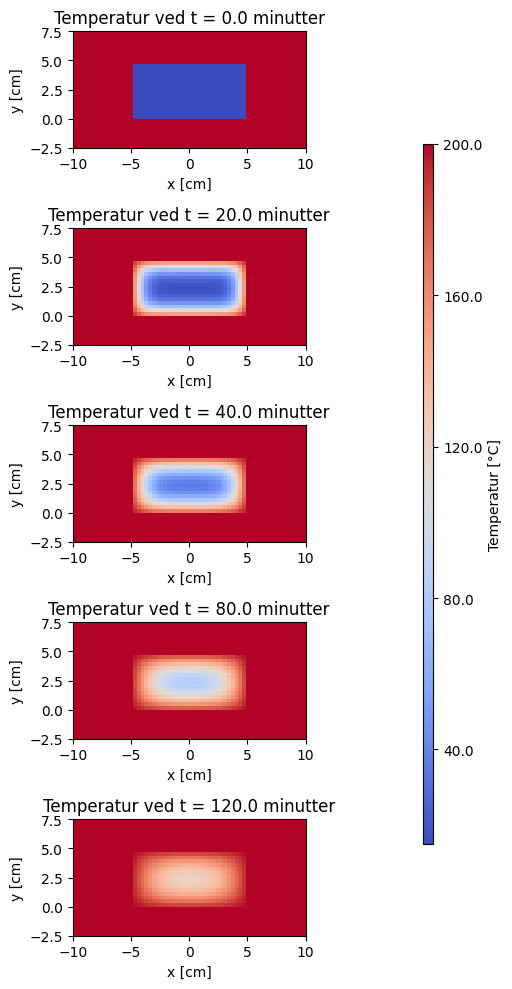

In [5]:
#
# Plotting av oppg 7

#   Lager figuren
fig, axs = plt.subplots(len(tider), 1, figsize=(5, 10))

# Setter inn riktige verdier på x- og y-akse
extent = [x_2.min(), x_2.max(), y_2.min(), y_2.max()]

# Lager plot for de forskjellige tidspunktene
for i, tid in enumerate(tider):
    im = axs[i].imshow(
        u_2[tid, :, :],
        cmap="coolwarm",
        origin="lower",
        extent=extent,
        aspect="equal",
        vmin=u_2.min(),
        vmax=u_2.max(),
    )
    axs[i].set_title(f"Temperatur ved t = {t[tid]:.1f} minutter")
    axs[i].set_xlabel("x [cm]")
    axs[i].set_ylabel("y [cm]")

# Felles fargeskala
# Lager en egen akse for fargeskalaen til høyre
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)

# Ryddigere tallformat
cbar.locator = MaxNLocator(nbins=6)  # maks 6 tick-verdier
cbar.formatter = FormatStrFormatter("%.1f")  # én desimal, ingen eksponent
cbar.update_ticks()
cbar.set_label("Temperatur [°C]")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # gjør plass til fargeskalaen
plt.show()